# Entraîner un générateur texte-vers-image avec Weli

Ce notebook entraîne réellement `text_to_image_mlp` sur le jeu de données intégré **Digits** de scikit-learn : 1 797 images manuscrites annotées, en niveaux de gris, de 8 × 8 pixels. Le texte de conditionnement est l'étiquette de chaque image (« chiffre cinq », etc.). Les poids sont optimisés avec rétropropagation et Adam ; ce n'est ni un modèle pré-entraîné ni une simple démonstration avec des poids aléatoires.

Il s'agit d'un petit exercice de génération conditionnelle, pas d'un générateur d'images réalistes haute résolution. Les exemples et les poids entraînés sont sauvegardés dans `training/generated/`.

In [9]:
# %pip install scikit-learn

In [12]:
# Si nécessaire, installer scikit-learn dans l'environnement du notebook :
# %pip install scikit-learn
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
import numpy as np
try:
    from sklearn.datasets import load_digits
except ModuleNotFoundError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.datasets import load_digits
# Ensure the actual package is installed in the notebook environment:

from sklearn.model_selection import train_test_split

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').exists()), None)
if ROOT is None:
    raise RuntimeError('Ouvrez ce notebook depuis le dépôt Weli afin de trouver pyproject.toml.')
sys.path.insert(0, str(ROOT))

from weli.losses import MSE
from weli.models import text_to_image_mlp
from weli.models.save_load import save_model
from weli.optimizers import Adam

SEED = 42
np.random.seed(SEED)
OUTPUT_DIR = ROOT / 'training' / 'generated'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Charger et préparer les exemples réels

Les pixels et les sorties du générateur sont normalisés dans `[-1, 1]`. Les embeddings de mots sont déterministes et servent seulement à convertir les courtes étiquettes en séquences numériques acceptées par Weli.

Exemples : 1437 entraînement, 360 validation
Entrée texte : (4, 16), sortie image aplatie : 64 pixels


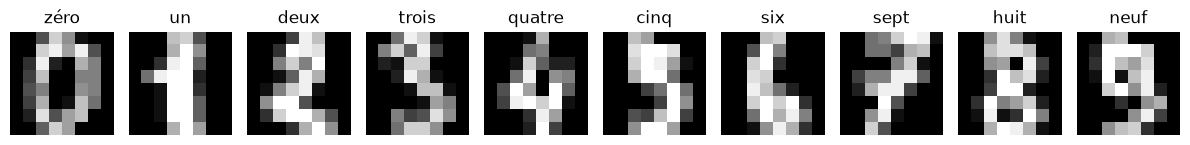

In [13]:
digits = load_digits()
digit_names = ('zéro', 'un', 'deux', 'trois', 'quatre', 'cinq', 'six', 'sept', 'huit', 'neuf')
captions = [f'chiffre {digit_names[int(label)]}' for label in digits.target]
images = (digits.images[..., None].astype(np.float32) / 8.0 - 1.0)
targets = images.reshape(len(images), -1)

TEXT_LENGTH = 4
EMBEDDING_DIM = 16

def word_vector(word):
    seed = int.from_bytes(hashlib.blake2b(word.encode('utf-8'), digest_size=8).digest(), 'little')
    return np.random.default_rng(seed).normal(0.0, 0.25, EMBEDDING_DIM).astype(np.float32)

def encode_caption(caption):
    encoded = np.zeros((TEXT_LENGTH, EMBEDDING_DIM), dtype=np.float32)
    for index, word in enumerate(caption.lower().split()[:TEXT_LENGTH]):
        encoded[index] = word_vector(word)
    return encoded

text_features = np.stack([encode_caption(caption) for caption in captions])
x_train, x_val, y_train, y_val, labels_train, labels_val = train_test_split(
    text_features, targets, digits.target, test_size=0.2, random_state=SEED, stratify=digits.target
)
print(f'Exemples : {len(x_train)} entraînement, {len(x_val)} validation')
print(f'Entrée texte : {x_train.shape[1:]}, sortie image aplatie : {y_train.shape[1]} pixels')
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for digit, ax in enumerate(axes):
    ax.imshow(digits.images[np.flatnonzero(digits.target == digit)[0]], cmap='gray', vmin=0, vmax=16)
    ax.set_title(digit_names[digit])
    ax.axis('off')
plt.tight_layout()

## 2. Construire et entraîner le modèle

La séparation validation est tenue à l'écart de l'entraînement. Réduisez le nombre d'époques pour un essai rapide ou augmentez-le pour prolonger l'expérience.

Epoch 1/100 - loss: 0.5613 - acc: 0.0217 - val_loss: 0.3803 - val_acc: 0.0120
Epoch 2/100 - loss: 0.3163 - acc: 0.0122 - val_loss: 0.2884 - val_acc: 0.0120
Epoch 3/100 - loss: 0.2734 - acc: 0.0122 - val_loss: 0.2671 - val_acc: 0.0172
Epoch 4/100 - loss: 0.2525 - acc: 0.0851 - val_loss: 0.2468 - val_acc: 0.0521
Epoch 5/100 - loss: 0.2307 - acc: 0.0395 - val_loss: 0.2225 - val_acc: 0.0318
Epoch 6/100 - loss: 0.2096 - acc: 0.0389 - val_loss: 0.2066 - val_acc: 0.0344
Epoch 7/100 - loss: 0.1978 - acc: 0.0355 - val_loss: 0.1950 - val_acc: 0.0505
Epoch 8/100 - loss: 0.1899 - acc: 0.0367 - val_loss: 0.1890 - val_acc: 0.0344
Epoch 9/100 - loss: 0.1847 - acc: 0.0409 - val_loss: 0.1848 - val_acc: 0.0344
Epoch 10/100 - loss: 0.1823 - acc: 0.0408 - val_loss: 0.1822 - val_acc: 0.0474
Epoch 11/100 - loss: 0.1796 - acc: 0.0485 - val_loss: 0.1804 - val_acc: 0.0474
Epoch 12/100 - loss: 0.1787 - acc: 0.0492 - val_loss: 0.1789 - val_acc: 0.0526
Epoch 13/100 - loss: 0.1766 - acc: 0.0507 - val_loss: 0.1774 

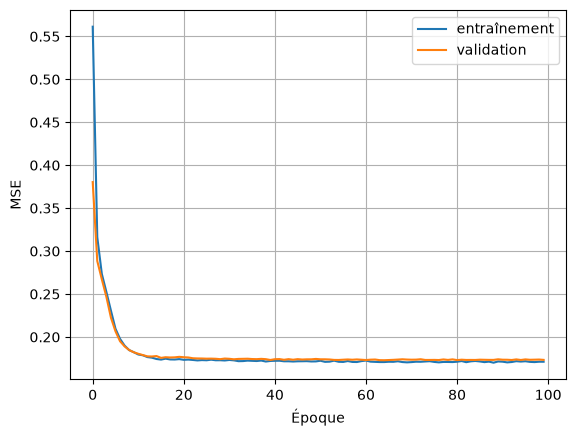

In [16]:
model = text_to_image_mlp(
    text_shape=(TEXT_LENGTH, EMBEDDING_DIM),
    image_shape=(8, 8, 1),
    hidden_units=32,
)
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    loss_fn=MSE(),
    optimizer=Adam(lr=0.003),
    verbose=1,
)

plt.plot(history['train_loss'], label='entraînement')
plt.plot(history['val_loss'], label='validation')
plt.xlabel('Époque')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

## 3. Générer, comparer et sauvegarder

Chaque prédiction est remodelée en image `8 × 8`. Les comparaisons validation permettent de voir ce que le modèle a effectivement appris. Ce petit générateur a tendance à produire un prototype moyen par classe.

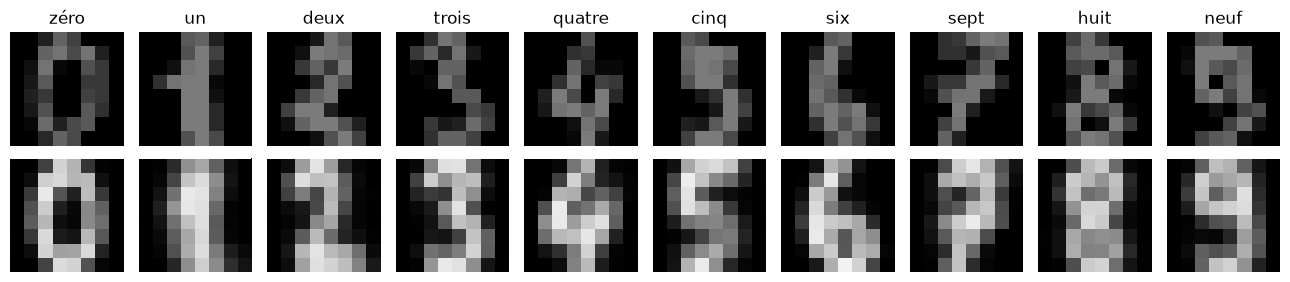

Modèle et images sauvegardés dans c:\Users\WIN11\Desktop\Weli\training\generated


In [22]:
chosen_digits = np.arange(10)
prompt_features = np.stack([encode_caption(f'chiffre {digit_names[d]}') for d in chosen_digits])
generated = model.predict(prompt_features).reshape(-1, 8, 8)

fig, axes = plt.subplots(2, 10, figsize=(13, 3))
for digit in chosen_digits:
    axes[0, digit].imshow(digits.images[np.flatnonzero(digits.target == digit)[0]], cmap='gray', vmin=1, vmax=32)
    axes[1, digit].imshow(generated[digit], cmap='gray', vmin=-1, vmax=1)
    axes[0, digit].set_title(digit_names[digit])
    axes[0, digit].axis('off')
    axes[1, digit].axis('off')
axes[0, 0].set_ylabel('Réel')
axes[1, 0].set_ylabel('Généré')
plt.tight_layout()
plt.show()

save_model(model, str(OUTPUT_DIR / 'text-to-image-digits.weli'))
np.save(OUTPUT_DIR / 'text-to-image-digits.npy', generated)
print(f'Modèle et images sauvegardés dans {OUTPUT_DIR}')